In [2]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download(
    "shreedhany/employee-salary-prediction-using-linear-regression"
)


Using Colab cache for faster access to the 'employee-salary-prediction-using-linear-regression' dataset.


In [3]:
print(path)

/kaggle/input/employee-salary-prediction-using-linear-regression


In [6]:
print(os.listdir(path))

['Dataset09-Employee-salary-prediction.csv']


In [7]:
df = pd.read_csv(os.path.join(path, "Dataset09-Employee-salary-prediction.csv"))

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [8]:
df.shape

(375, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


COLUMN NAME CHANGE

In [10]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [11]:
df.columns=['Age','Gender','Degree','Job_Sector','Experience','Salary']

In [12]:
df.columns

Index(['Age', 'Gender', 'Degree', 'Job_Sector', 'Experience', 'Salary'], dtype='object')

NULL VALUE HANDLING


In [13]:
df.isnull().sum()

,0
Age,2
Gender,2
Degree,2
Job_Sector,2
Experience,2
Salary,2


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Age,0
Gender,0
Degree,0
Job_Sector,0
Experience,0
Salary,0


In [16]:
df.shape

(373, 6)

DUPLICATE VALUE HANDLING

In [17]:
df[df.duplicated()].shape

(49, 6)

In [18]:
df = df.drop_duplicates(keep = 'first')

In [19]:
df[df.duplicated()].shape

(0, 6)

In [20]:
df.shape

(324, 6)

In [21]:
df.dtypes

,0
Age,float64
Gender,object
Degree,object
Job_Sector,object
Experience,float64
Salary,float64


EDA-VISULIZATION

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Degree'>

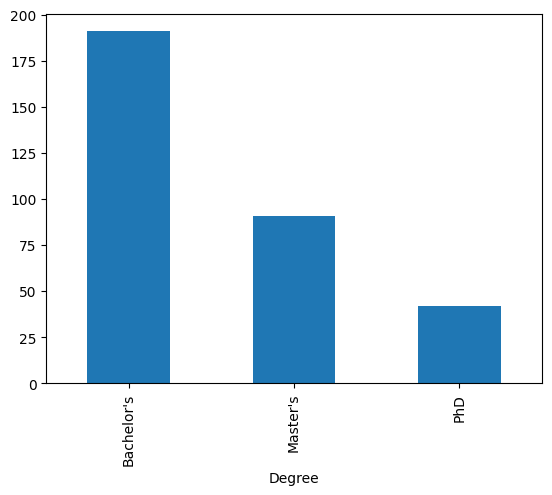

In [23]:
df['Degree'].value_counts().plot(kind='bar')

<Axes: xlabel='Job_Sector'>

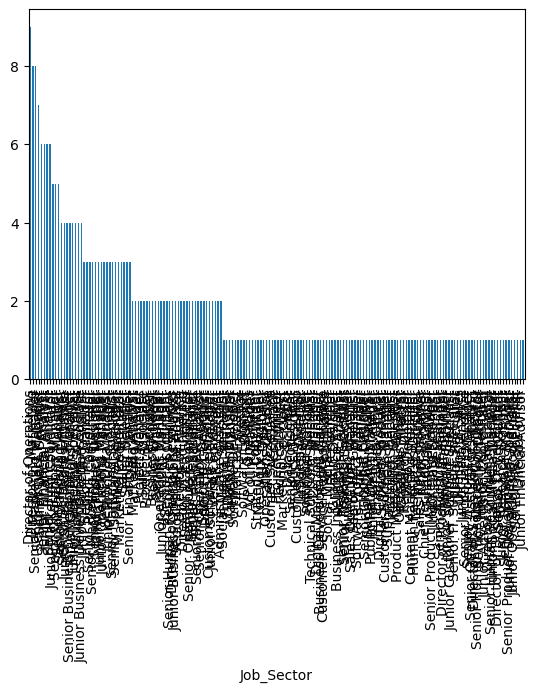

In [24]:
df['Job_Sector'].value_counts().plot(kind='bar')

<Axes: ylabel='Degree'>

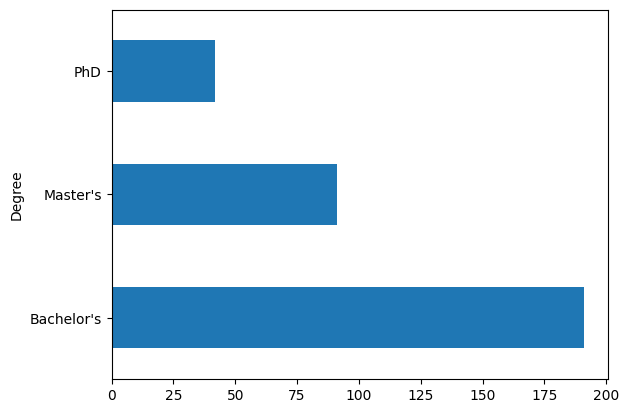

In [25]:
df['Degree'].value_counts().plot(kind='barh')

<Axes: xlabel='Age', ylabel='Experience'>

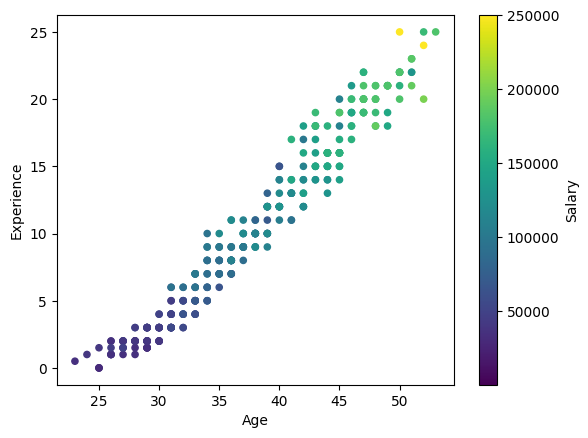

In [26]:
df.plot.scatter(x='Age',y='Experience',c='Salary')

ENCODING (STRING -> INT)

In [27]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Degree'] = label_encoder.fit_transform(df['Degree'])
df['Job_Sector'] = label_encoder.fit_transform(df['Job_Sector'])
df.head()

,Age,Gender,Degree,Job_Sector,Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


INDEPENDENT AND DEPENDENT FEARTURE


In [28]:
X=df.iloc[:,0:5]
Y=df.iloc[:,-1]

In [29]:
X.head()

,Age,Gender,Degree,Job_Sector,Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0


In [30]:
Y.head()

,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


TRAIN TEST SPLIT

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=0)


In [32]:
X_train.shape

(291, 5)

In [33]:
X_test.shape

(33, 5)

In [34]:
Y_train.shape

(291,)

In [35]:
Y_test.shape

(33,)

FEATURE SCALING (STANDARIZING DATASET)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df['Age'] = scaler.fit_transform(df[['Age']])
df['Experience'] = scaler.fit_transform(df[['Experience']])

MODEL TRAIN

In [37]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
regressor=LinearRegression()
regressor.fit(X_train,Y_train)

LinearRegression()

CROSS VALIDATION

In [38]:
msse=cross_val_score(regressor,X_train,Y_train,scoring='neg_mean_squared_error',cv=5)
print(msse)

[-2.75842134e+08 -1.93431491e+08 -3.28836796e+08 -2.48727061e+08
 -3.07506975e+08]


In [39]:
import numpy as np
np.mean(msse)

np.float64(-270868891.440967)

PREDICTION

In [40]:
Y_predict=regressor.predict(X_test)
Y_predict

array([ 63389.91497608, 102931.87261458, 132994.74354608,  63530.81728657,
        46475.52593161,  41262.28117294,  98789.38254313,  83905.73615326,
       185902.51577618,  46834.18635832, 124591.92389111, 150618.44532428,
        38421.82438942,  48751.06609203, 186756.22353073,  38050.35466176,
       105215.19517138,  89349.5483291 , 137593.3415473 , 124777.90148507,
       127544.3973962 , 147075.20978106, 172957.44851016,  45125.74869509,
       120182.57047087, 174274.96030908,  40325.89482218, 156385.75701099,
        61346.90183872, 120653.24761914, 166661.68849733,  89859.96076136,
        51675.96138932])

GRAPH


/tmp/ipykernel_1988/2525937584.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_test-Y_predict)


<Axes: xlabel='Salary', ylabel='Density'>

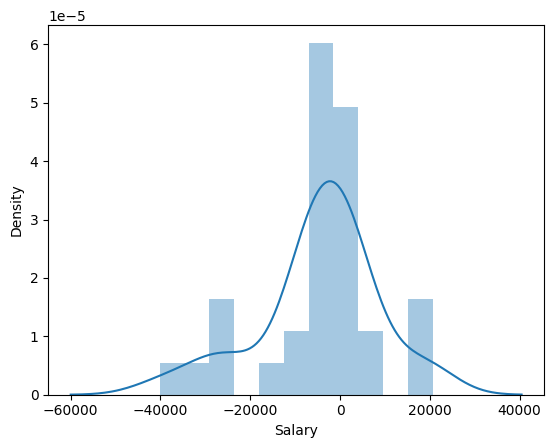

In [41]:
sns.distplot(Y_test-Y_predict)

In [43]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_predict)
r2

0.9109277265452715

ERROR

In [45]:
df=pd.DataFrame({'Actual':Y_test,'Predicted':Y_predict})


In [46]:
df['Error']=df['Actual']-df['Predicted']

In [47]:
df['abs_error']=abs(df['Error'])

MEAN ABSOLUTE ERROR

In [48]:
from sklearn import metrics
print(metrics.mean_absolute_error(Y_test,Y_predict))

9537.39297690621


MEAN SQUARED ERROR

In [49]:
print(metrics.mean_squared_error(Y_test,Y_predict))

192859057.46455845


ROOT MEAN SQUARED ERROR

In [50]:
print(np.sqrt(metrics.mean_squared_error(Y_test,Y_predict)))

13887.37043016274


GRAPH -> ACTUAL VS PREDICTED

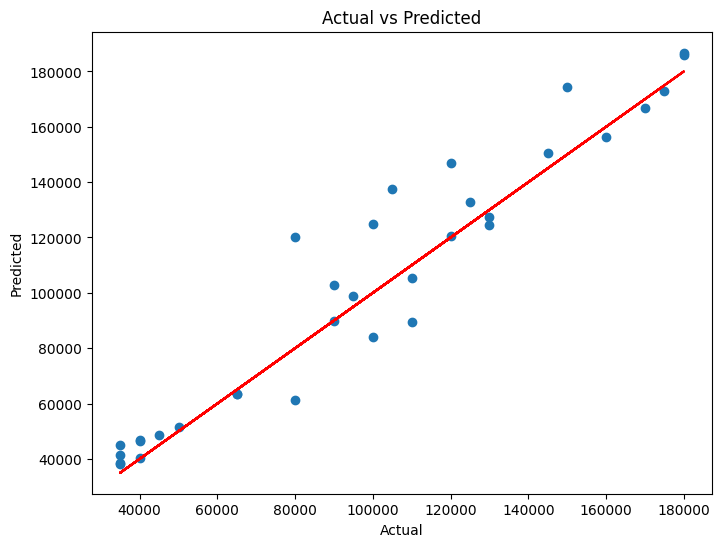

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test,Y_predict)
plt.plot(Y_test,Y_test,'r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

NEW EMPLOYEE

In [60]:
new_employee=[[35,1,2,130,14]]
predicted_salary=regressor.predict(new_employee)
print("Predicted Salary for the new employee:",predicted_salary[0])

Predicted Salary for the new employee: 132562.26857737094


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
